# Modul 10 - Clustering
## K-Means + K-Modes (Kelompok Ganjil)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kmodes.kmodes import KModes

In [2]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

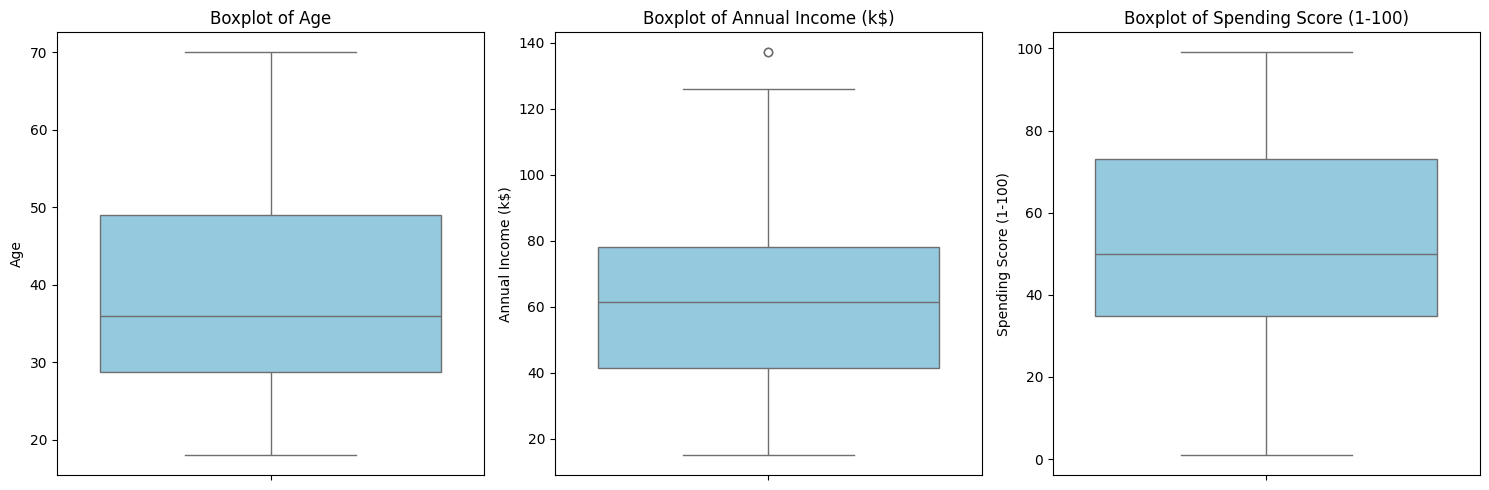

In [6]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

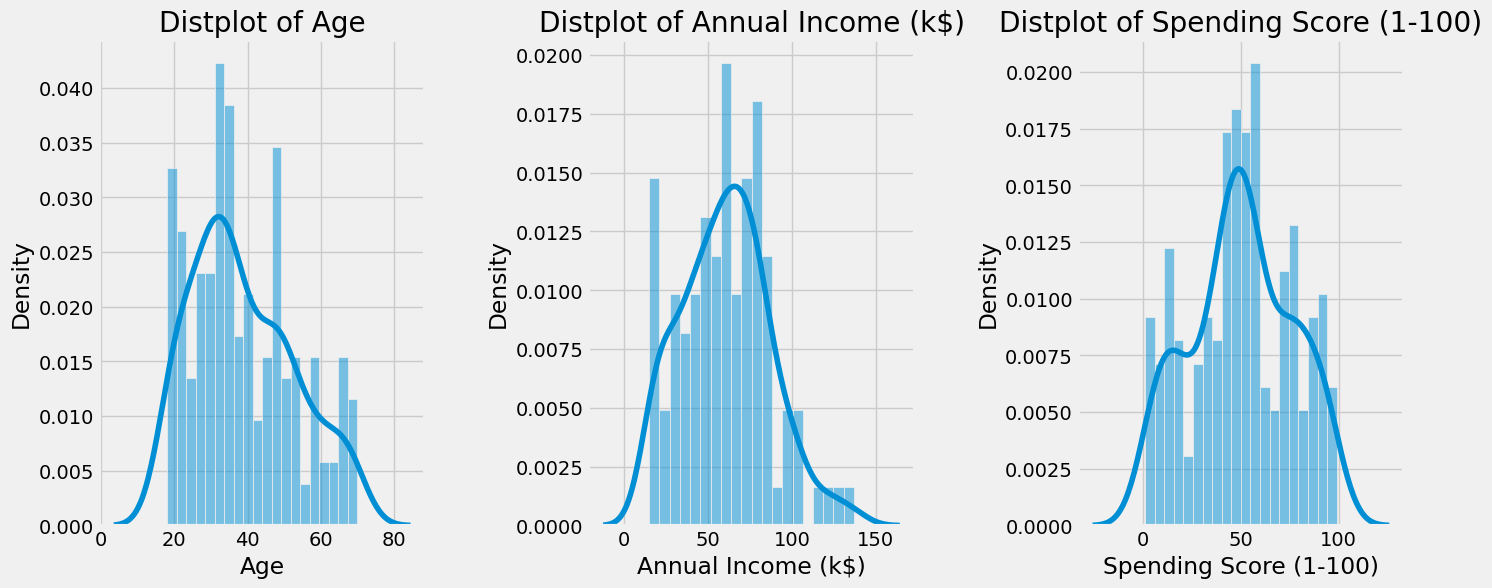

In [7]:
plt.style.use('fivethirtyeight')
plt.figure(1, figsize=(15, 6))
n = 0
for x in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    n += 1
    plt.subplot(1, 3, n)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    sns.histplot(df[x], kde=True, stat="density", kde_kws=dict(cut=3), bins=20)
    plt.title('Distplot of {}'.format(x))
plt.show()

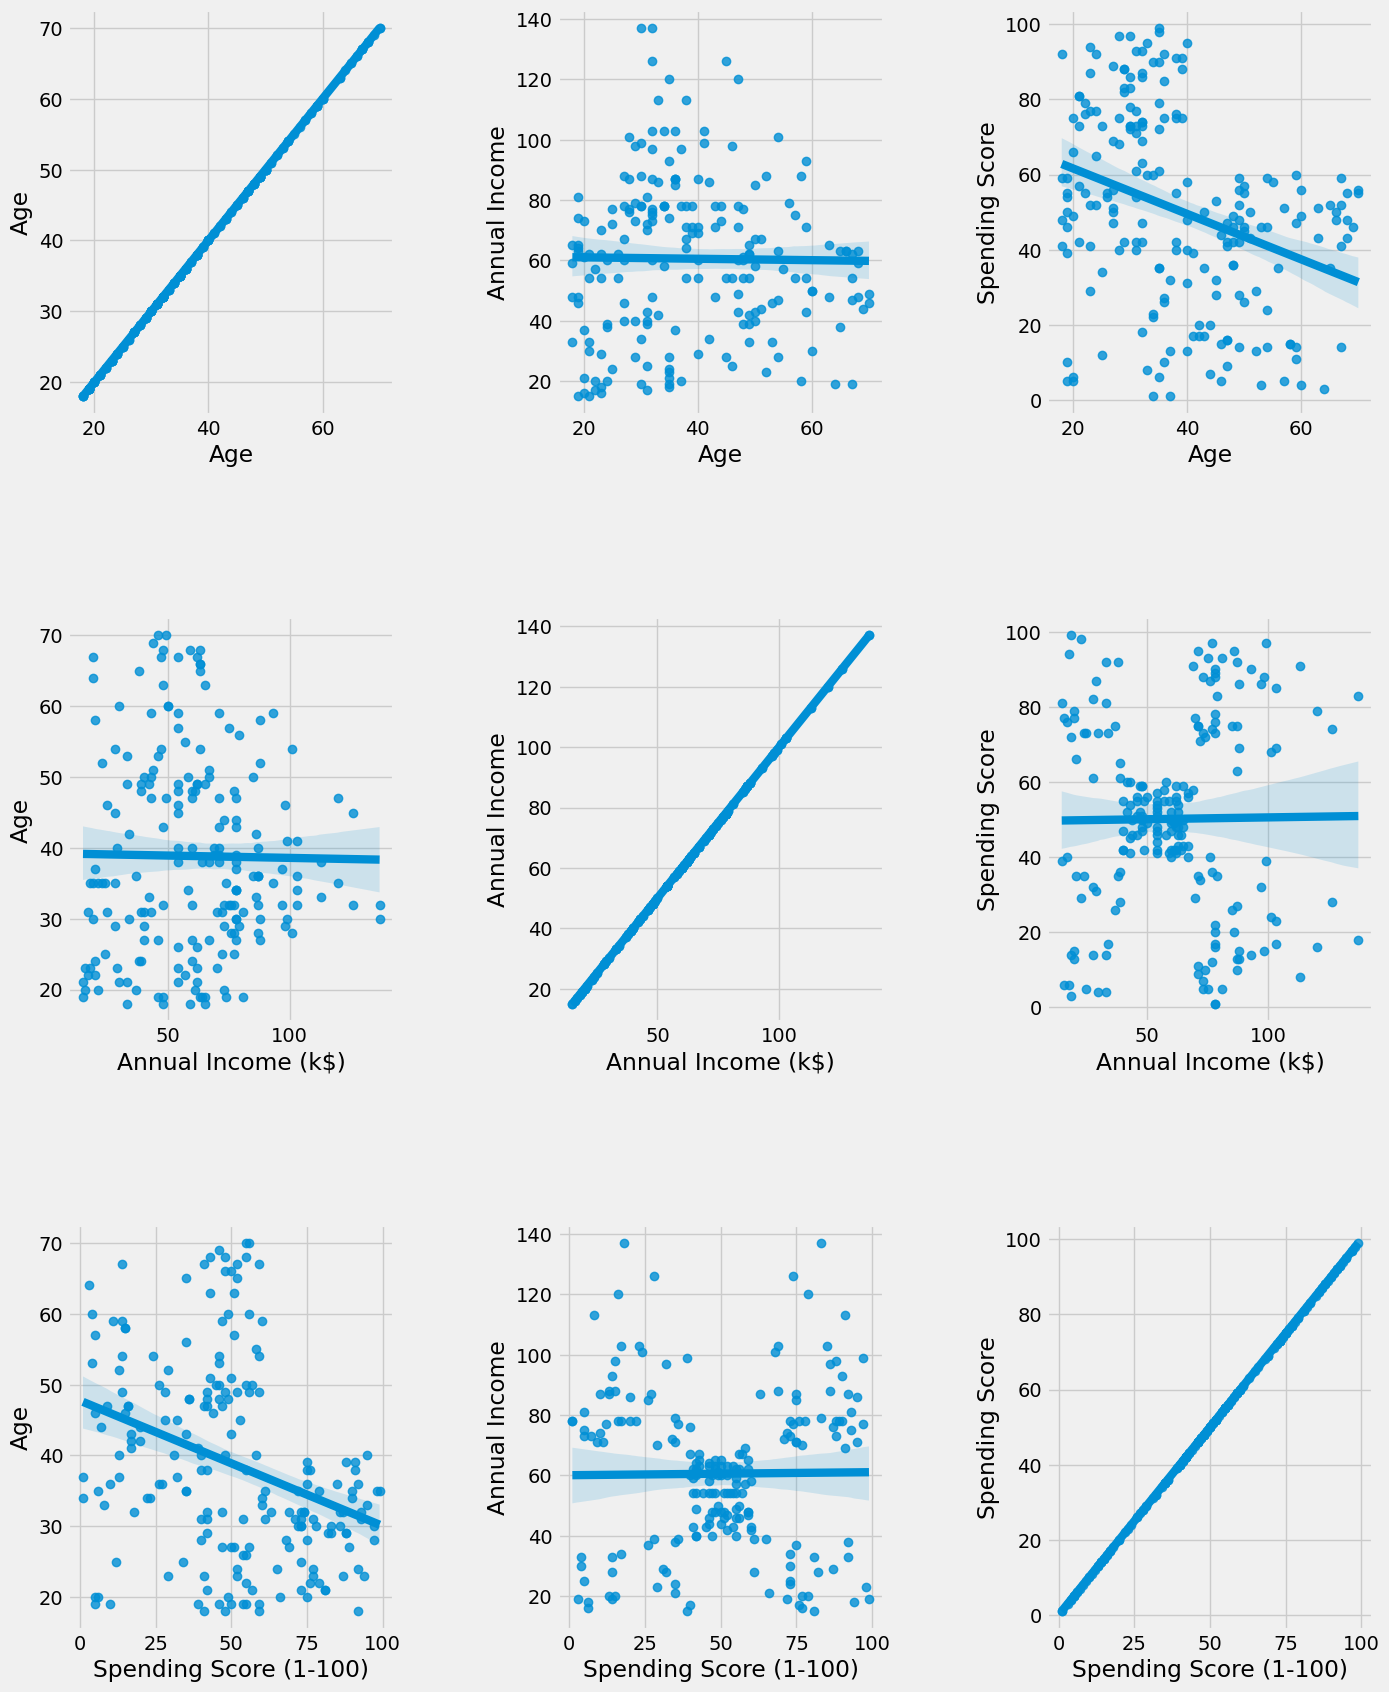

In [8]:
plt.figure(1, figsize=(15, 20))
n = 0
for x in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    for y in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
        n += 1
        plt.subplot(3, 3, n)
        plt.subplots_adjust(hspace=0.5, wspace=0.5)
        sns.regplot(x=x, y=y, data=df)
        plt.ylabel(y.split()[0]+' '+y.split()[1] if len(y.split()) > 1 else y)
plt.show()

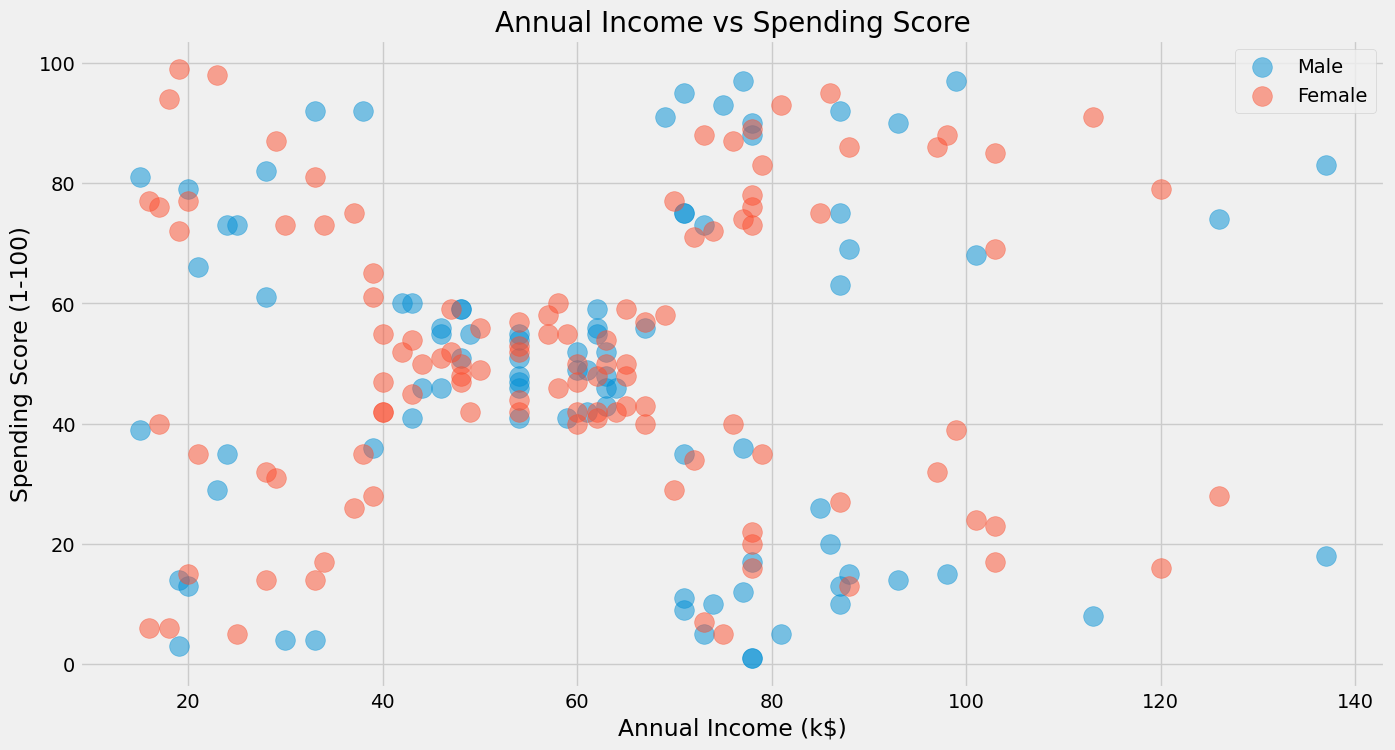

In [9]:
plt.figure(1, figsize=(15, 8))
for gender in ['Male', 'Female']:
    plt.scatter(x='Annual Income (k$)', y='Spending Score (1-100)',
                data=df[df['Gender'] == gender], s=200, alpha=0.5, label=gender)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')
plt.legend()
plt.show()

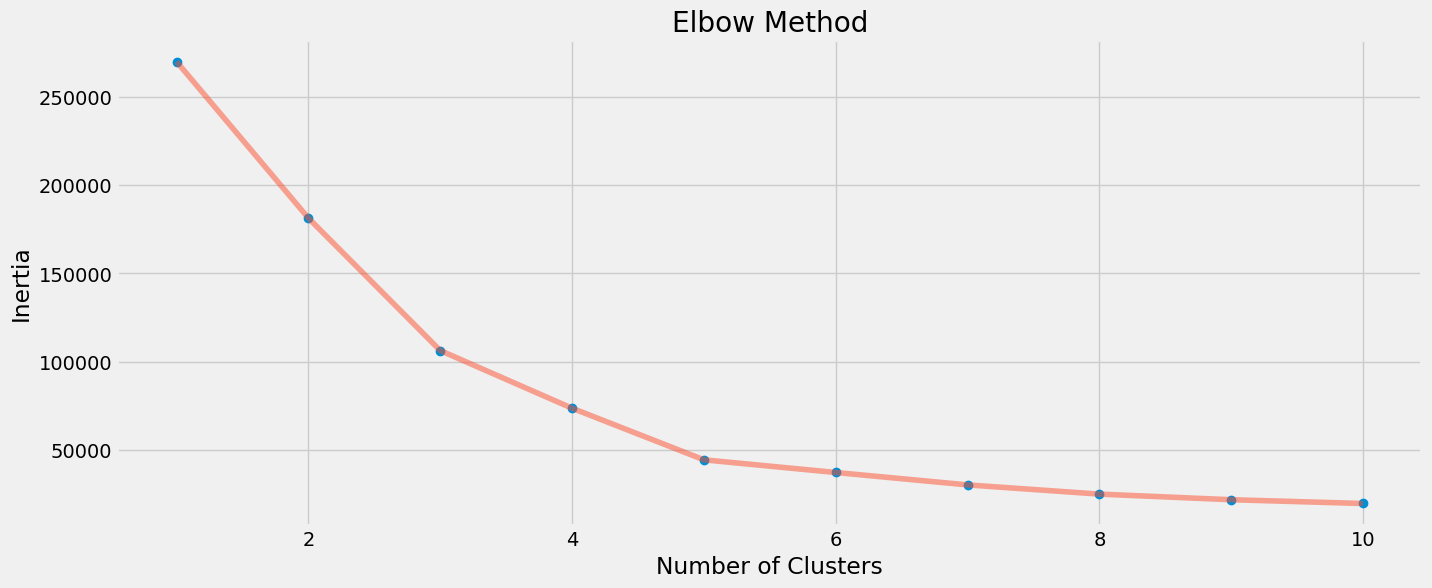

In [10]:
X1 = df[['Annual Income (k$)', 'Spending Score (1-100)']].iloc[:, :].values
inertia = []
for n in range(1, 11):
    algorithm = KMeans(n_clusters=n, init='k-means++', n_init=10, max_iter=300, random_state=111)
    algorithm.fit(X1)
    inertia.append(algorithm.inertia_)

plt.figure(1, figsize=(15, 6))
plt.plot(range(1, 11), inertia, 'o')
plt.plot(range(1, 11), inertia, '-', alpha=0.5)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [11]:
algorithm = KMeans(n_clusters=5, init='k-means++', n_init=10, max_iter=300,
                   tol=0.0001, random_state=111, algorithm='elkan')
algorithm.fit(X1)
labels2 = algorithm.labels_
centroids2 = algorithm.cluster_centers_

In [12]:
labels2 = algorithm.labels_
centroids2 = algorithm.cluster_centers_
step = 0.02
x_min, x_max = X1[:, 0].min() - 1, X1[:, 0].max() + 1
y_min, y_max = X1[:, 1].min() - 1, X1[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, step), np.arange(y_min, y_max, step))
Z1 = algorithm.predict(np.c_[xx.ravel(), yy.ravel()])

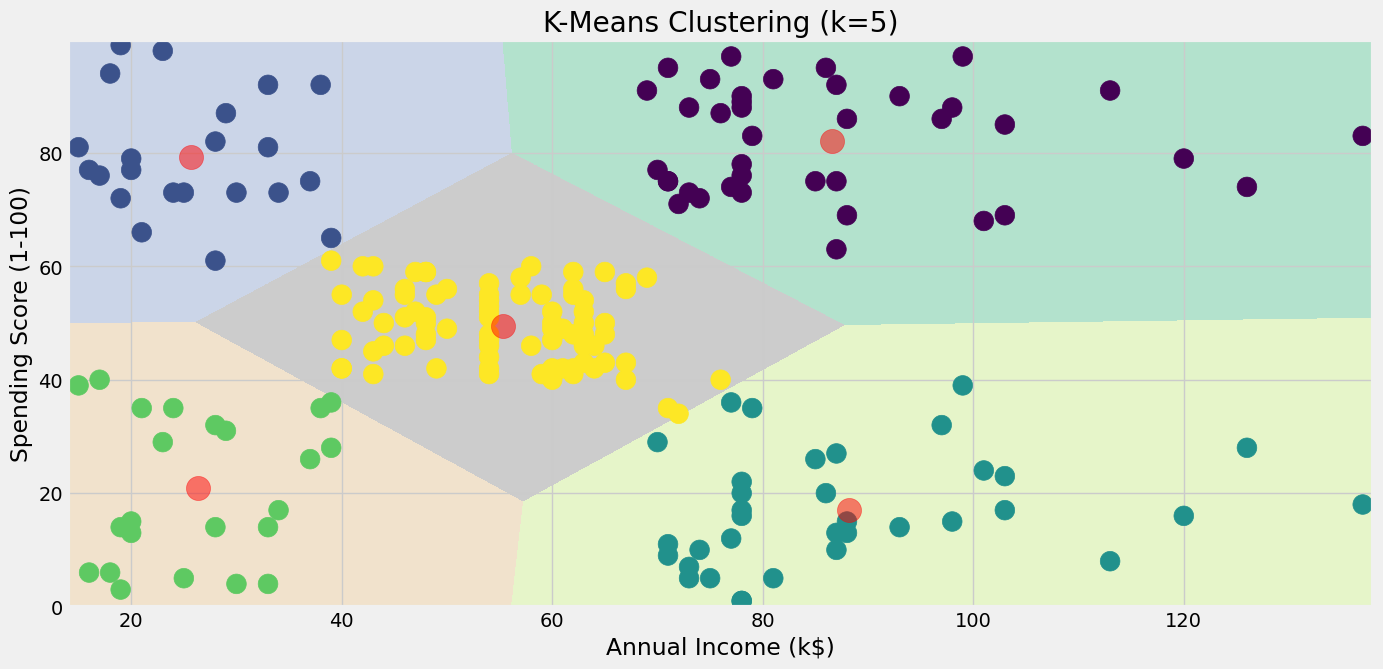

In [13]:
plt.figure(1, figsize=(15, 7))
plt.clf()
Z1 = Z1.reshape(xx.shape)
plt.imshow(Z1, interpolation='nearest',
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap=plt.cm.Pastel2, aspect='auto', origin='lower')
plt.scatter(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, c=labels2, s=200)
plt.scatter(x=centroids2[:, 0], y=centroids2[:, 1], s=300, c='red', alpha=0.5)
plt.ylabel('Spending Score (1-100)')
plt.xlabel('Annual Income (k$)')
plt.title('K-Means Clustering (k=5)')
plt.show()

In [14]:
score2 = silhouette_score(X1, labels2)
print("Silhouette Score:", score2)

Silhouette Score: 0.553931997444648


## K-Modes Clustering

In [15]:
df_kmodes = df.copy()

df_kmodes['Age_Group'] = pd.cut(df['Age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['Remaja', 'Dewasa Muda', 'Dewasa', 'Paruh Baya', 'Lansia'])

df_kmodes['Income_Group'] = pd.cut(df['Annual Income (k$)'],
    bins=[0, 30, 60, 90, 120, 200],
    labels=['Sangat Rendah', 'Rendah', 'Menengah', 'Tinggi', 'Sangat Tinggi'])

df_kmodes['Spending_Group'] = pd.cut(df['Spending Score (1-100)'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['Sangat Rendah', 'Rendah', 'Menengah', 'Tinggi', 'Sangat Tinggi'])

X_kmodes = df_kmodes[['Gender', 'Age_Group', 'Income_Group', 'Spending_Group']].astype(str)
X_kmodes.head(10)

,Gender,Age_Group,Income_Group,Spending_Group
0,Male,Remaja,Sangat Rendah,Rendah
1,Male,Remaja,Sangat Rendah,Sangat Tinggi
2,Female,Remaja,Sangat Rendah,Sangat Rendah
3,Female,Remaja,Sangat Rendah,Tinggi
4,Female,Dewasa Muda,Sangat Rendah,Rendah
5,Female,Remaja,Sangat Rendah,Tinggi
6,Female,Dewasa Muda,Sangat Rendah,Sangat Rendah
7,Female,Remaja,Sangat Rendah,Sangat Tinggi
8,Male,Lansia,Sangat Rendah,Sangat Rendah
9,Female,Dewasa Muda,Sangat Rendah,Tinggi


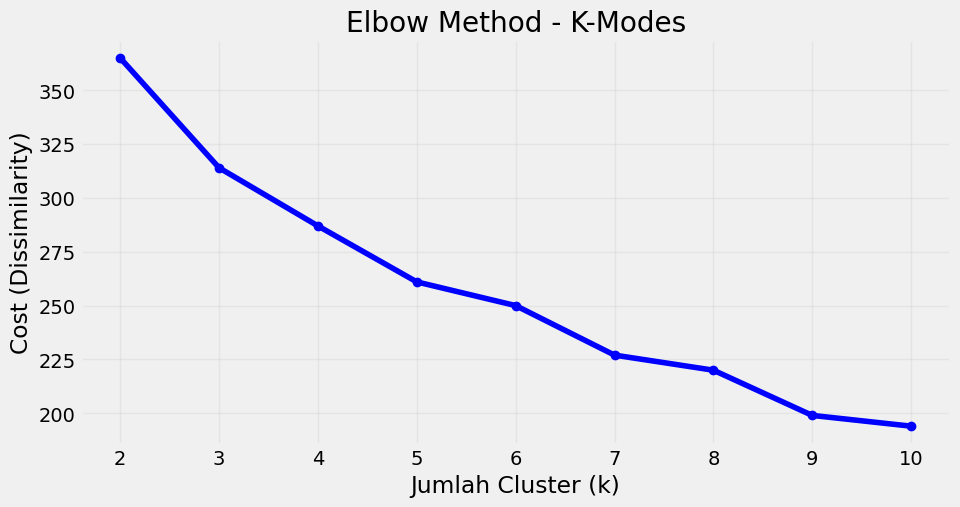

In [16]:
cost = []
K_range = range(2, 11)
for k in K_range:
    km = KModes(n_clusters=k, init='Huang', n_init=10, verbose=0)
    km.fit(X_kmodes)
    cost.append(km.cost_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, cost, 'bo-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Cost (Dissimilarity)')
plt.title('Elbow Method - K-Modes')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
km_model = KModes(n_clusters=4, init='Huang', n_init=10, verbose=0, random_state=42)
clusters_kmodes = km_model.fit_predict(X_kmodes)

df_kmodes['KModes_Cluster'] = clusters_kmodes
pd.DataFrame(km_model.cluster_centroids_, columns=X_kmodes.columns)

,Gender,Age_Group,Income_Group,Spending_Group
0,Female,Paruh Baya,Rendah,Menengah
1,Female,Dewasa,Menengah,Rendah
2,Female,Dewasa Muda,Sangat Rendah,Tinggi
3,Male,Dewasa Muda,Menengah,Sangat Tinggi


In [18]:
df_kmodes['KModes_Cluster'].value_counts().sort_index()

KModes_Cluster
0    82
1    37
2    37
3    44
Name: count, dtype: int64

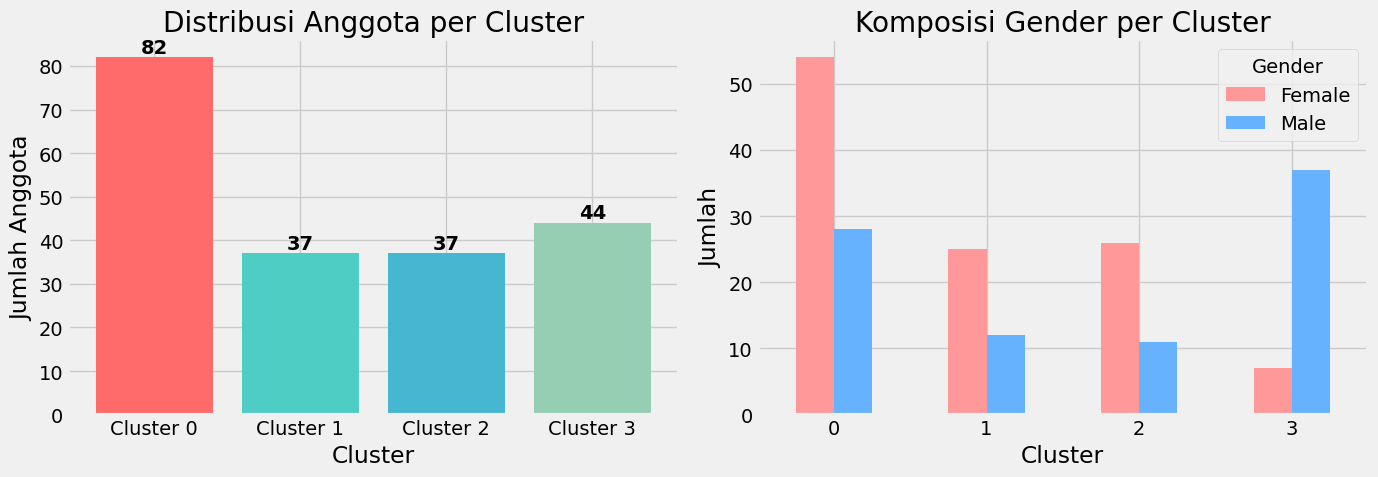

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_counts = df_kmodes['KModes_Cluster'].value_counts().sort_index()
axes[0].bar(
    [f'Cluster {i}' for i in cluster_counts.index],
    cluster_counts.values,
    color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Jumlah Anggota')
axes[0].set_title('Distribusi Anggota per Cluster')
for i, v in enumerate(cluster_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

gender_cluster = pd.crosstab(df_kmodes['KModes_Cluster'], df_kmodes['Gender'])
gender_cluster.plot(kind='bar', ax=axes[1], color=['#FF9999', '#66B2FF'], rot=0)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Jumlah')
axes[1].set_title('Komposisi Gender per Cluster')
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()

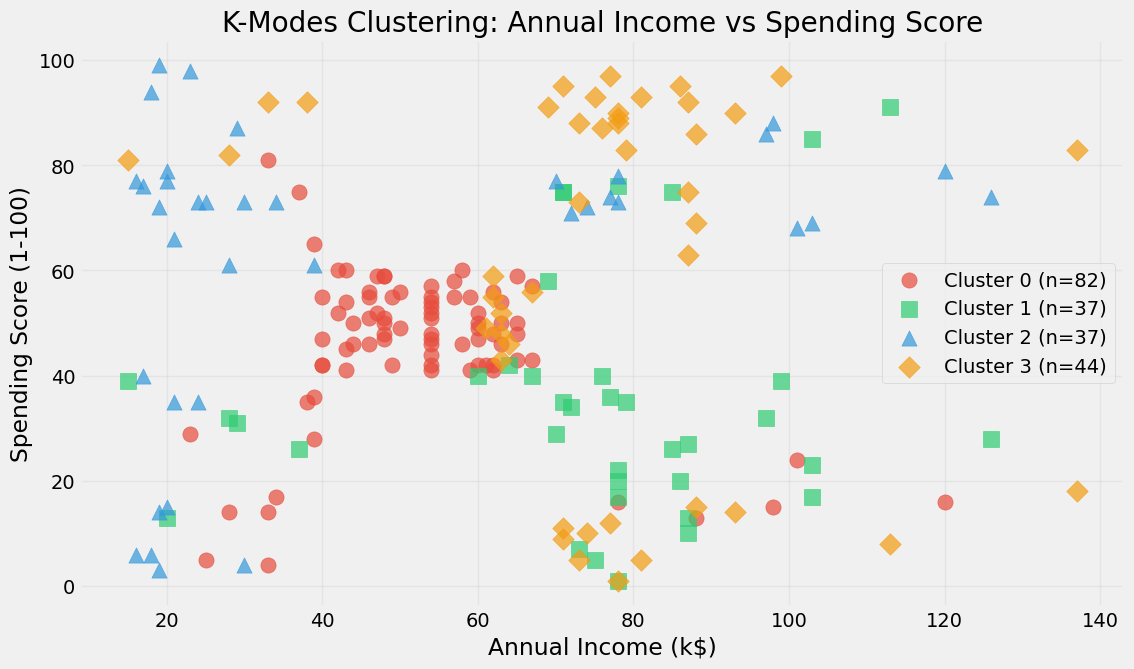

In [20]:
colors = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12']
markers = ['o', 's', '^', 'D']

plt.figure(figsize=(12, 7))
for i in range(4):
    mask = df_kmodes['KModes_Cluster'] == i
    plt.scatter(
        df_kmodes.loc[mask, 'Annual Income (k$)'],
        df_kmodes.loc[mask, 'Spending Score (1-100)'],
        c=colors[i], marker=markers[i], s=120, alpha=0.7,
        label=f'Cluster {i} (n={mask.sum()})'
    )
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Modes Clustering: Annual Income vs Spending Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
for c in range(4):
    subset = df_kmodes[df_kmodes['KModes_Cluster'] == c]
    print(f"Cluster {c} ({len(subset)} pelanggan):")
    print(f"  Gender   : {subset['Gender'].value_counts().to_dict()}")
    print(f"  Age Group: {subset['Age_Group'].value_counts().idxmax()} (avg: {subset['Age'].mean():.1f})")
    print(f"  Income   : {subset['Income_Group'].value_counts().idxmax()} (avg: ${subset['Annual Income (k$)'].mean():.1f}k)")
    print(f"  Spending : {subset['Spending_Group'].value_counts().idxmax()} (avg score: {subset['Spending Score (1-100)'].mean():.1f})")
    print()

Cluster 0 (82 pelanggan):
  Gender   : {'Female': 54, 'Male': 28}
  Age Group: Paruh Baya (avg: 43.8)
  Income   : Rendah (avg: $53.0k)
  Spending : Menengah (avg score: 45.6)

Cluster 1 (37 pelanggan):
  Gender   : {'Female': 25, 'Male': 12}
  Age Group: Dewasa (avg: 39.0)
  Income   : Menengah (avg: $75.0k)
  Spending : Rendah (avg score: 35.5)

Cluster 2 (37 pelanggan):
  Gender   : {'Female': 26, 'Male': 11}
  Age Group: Dewasa Muda (avg: 32.8)
  Income   : Sangat Rendah (avg: $44.9k)
  Spending : Tinggi (avg score: 62.3)

Cluster 3 (44 pelanggan):
  Gender   : {'Male': 37, 'Female': 7}
  Age Group: Dewasa Muda (avg: 34.7)
  Income   : Menengah (avg: $75.8k)
  Spending : Sangat Tinggi (avg score: 60.9)

